In [ ]:
import pandas as pd
import sklearn
from google.colab import files
import gdown
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from google.colab import files
import hdbscan
import umap
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from itertools import product

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_ID = "1K8s_CPaSq4bW27oJalN-K8HlwTxHIWGP"
DATA_NAME = "Run200_Wave_0_1.txt"

# Загрузка и изучение датасета

In [ ]:
gdown.download(id=DATA_ID, output=DATA_NAME)
data = pd.read_csv(DATA_NAME, sep=' ', header=None, skipinitialspace=True)
data.head()

Downloading...
From: https://drive.google.com/uc?id=1K8s_CPaSq4bW27oJalN-K8HlwTxHIWGP
To: /content/Run200_Wave_0_1.txt
100%|██████████| 71.3M/71.3M [00:00<00:00, 190MB/s]


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


In [ ]:
service_df = data.iloc[:, :4].copy()
data.drop(columns=[0, 1, 2, 3, 504], inplace=True)
data.columns = list(range(500))
service_df.head()

,0,1,2,3
0,2890276,357,113,500
1,4928764,740,359,500
2,9630204,162,499,500
3,15798632,841,123,500
4,20637296,412,348,500


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0
...,...,...,...,...,...,...,...,...
495,23479.0,14822.317092,3.232245,14801.0,14820.0,14823.0,14824.0,14834.0
496,23479.0,14822.279399,3.268458,14798.0,14820.0,14823.0,14824.0,14833.0
497,23479.0,14822.278163,3.251192,14804.0,14820.0,14823.0,14824.0,14834.0
498,23479.0,14822.287789,3.253340,14800.0,14820.0,14823.0,14824.0,14833.0


In [ ]:
print(f"Размер датасета: {data.shape}")
print(f"Общее число пропусков: {data.isna().sum().sum()}")

Размер датасета: (23479, 500)
Общее число пропусков: 0


# EDA

Подготовка формы сигнала

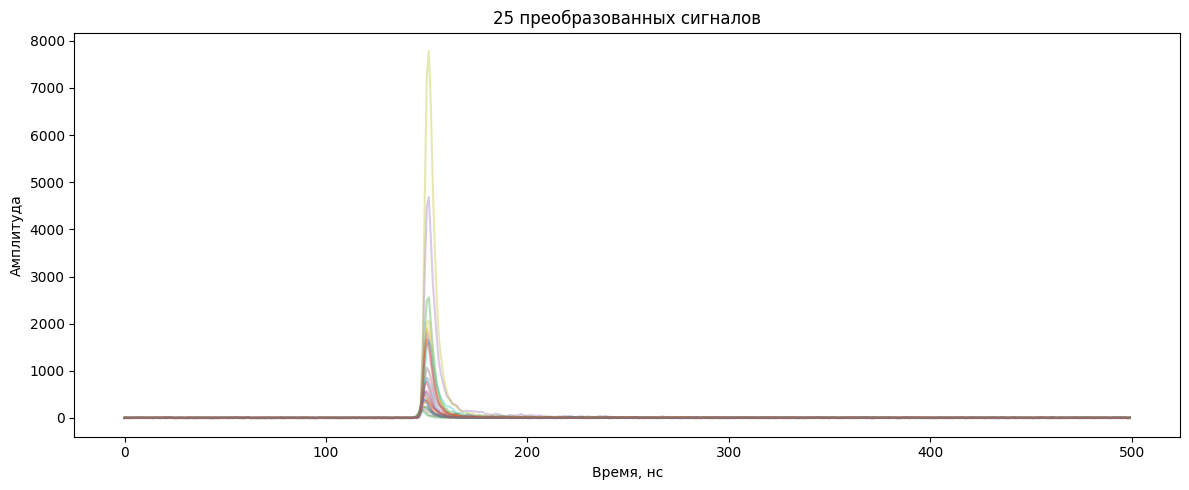

In [ ]:
X_signal = (2**14 - data.astype('float32') - 1560).to_numpy(dtype=np.float32)

plt.figure(figsize=(12, 5))
for i in range(25):
    plt.plot(X_signal[i], alpha=0.35)
plt.title('25 преобразованных сигналов')
plt.xlabel('Время, нс')
plt.ylabel('Амплитуда')
plt.tight_layout()
plt.show()

In [ ]:
# Вспомогательные функции

def first_consecutive_true(mask, consecutive=3):
    """Находит первый индекс, где подряд идут consecutive значений True"""
    mask = np.asarray(mask, dtype=bool)
    run = 0
    for i, v in enumerate(mask):
        run = run + 1 if v else 0
        if run >= consecutive:
            return i - consecutive + 1
    return None


def find_signal_end(y, peak_idx, noise_std, end_sigma=3.0, consecutive=3):
    """Находит конец импульса после пика"""
    thr = end_sigma * max(float(noise_std), 1e-6)
    tail = y[peak_idx:]
    below = tail <= thr
    local = first_consecutive_true(below, consecutive=consecutive)
    if local is None:
        return len(y) - 1
    return min(peak_idx + local, len(y) - 1)


def fwhm_width(seg):
    """Считает FWHM (Full Width at Half Maximum) - ширину сигнала на половине максимума"""
    if len(seg) == 0:
        return np.nan
    peak = np.max(seg)
    if peak <= 0:
        return np.nan
    half = peak / 2.0
    idx = np.where(seg >= half)[0]
    if len(idx) == 0:
        return np.nan
    return float(idx[-1] - idx[0] + 1)

# Feature Engineering

In [ ]:
# Извлечение признаков

def extract_features(X_signal, noise_window=140, short_gate=18):
    """
    Возвращает:
      features   - DataFrame с физическими признаками
      cropped    - список усеченных импульсов
    """
    rows = []
    cropped = []

    for x in X_signal:
        baseline = float(np.mean(x[:noise_window]))
        noise_std = float(np.std(x[:noise_window]) + 1e-6)

        y = x - baseline
        peak_idx = int(np.argmax(y))
        peak_amp = float(max(y[peak_idx], 0.0))

        signal_end_idx = find_signal_end(
            y=y,
            peak_idx=peak_idx,
            noise_std=noise_std,
            end_sigma=3.0,
            consecutive=3,
        )

        seg = np.clip(y[peak_idx:signal_end_idx + 1], 0.0, None)
        cropped.append(seg)

        signal_length = int(len(seg))
        area_total = float(np.sum(seg) + 1e-6)

        head_len = min(short_gate, signal_length)
        area_head = float(np.sum(seg[:head_len]) + 1e-6)
        area_tail = float(area_total - area_head)

        psd = float(area_tail / area_total)

        time_to_peak = max(peak_idx, 1)
        decay_len = max(signal_end_idx - peak_idx, 1)

        energy = float(np.sum(seg ** 2))
        if signal_length > 0:
            mean_seg = float(np.mean(seg))
            std_seg = float(np.std(seg))
            com = float(np.sum(np.arange(signal_length) * seg) / (np.sum(seg) + 1e-6))
            width = fwhm_width(seg)
        else:
            mean_seg = np.nan
            std_seg = np.nan
            com = np.nan
            width = np.nan

        rows.append({
            "baseline": baseline,
            "noise_std": noise_std,
            "peak_idx": peak_idx,
            "peak_amp": peak_amp,
            "peak_to_noise": float(peak_amp / noise_std),
            "signal_end_idx": signal_end_idx,
            "signal_length": signal_length,
            "time_to_peak": time_to_peak,
            "area_total": area_total,
            "area_head": area_head,
            "area_tail": area_tail,
            "psd": psd,
            "rise_slope": float(peak_amp / time_to_peak),
            "fall_slope": float(peak_amp / decay_len),
            "energy": energy,
            "mean_seg": mean_seg,
            "std_seg": std_seg,
            "center_of_mass": com,
            "fwhm": width,
        })

    features = pd.DataFrame(rows)
    return features, cropped



In [ ]:
features, cropped_signals = extract_features(X_signal)

# Предподготовка

In [ ]:
# набор на 0.46
FEATURE_COLS = [
    "peak_amp",
    "peak_to_noise",
    "signal_length",
    "area_total",
    "psd",
]

# на 0.38
# FEATURE_COLS = list(features.columns)

# 0.38
# FEATURE_COLS = ["peak_amp", "area_total", "psd", "signal_length"]

# 0.38
# FEATURE_COLS = ["peak_amp", "area_total", "area_tail", "psd", "signal_length"]

REDUCER = "pca"
PCA_VAR = 0.99


In [ ]:
X = features[FEATURE_COLS].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

print("X shape:", X.shape)
display(X.head())

X shape: (23479, 5)


,peak_amp,peak_to_noise,signal_length,area_total,psd
0,529.964294,193.994508,54,3234.072021,0.168430
1,1901.257202,699.340224,39,9435.027344,0.040212
2,2557.850098,1058.283715,50,10678.500000,0.043096
3,564.599976,203.316815,41,3454.600098,0.109072
4,1793.500000,670.061673,33,8606.500000,0.034102


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (23479, 5)


Снижение размерности

In [ ]:
pca095 = PCA(n_components=0.95, random_state=RANDOM_STATE)
pca099 = PCA(n_components=0.99, random_state=RANDOM_STATE)
X_reduced_095 = pca095.fit_transform(X_scaled)
X_reduced_099 = pca099.fit_transform(X_scaled)

data_dict = {
    "X_reduced_095": X_reduced_095,
    "X_reduced_099": X_reduced_099,
}

print(f"Форма с 0.95: {X_reduced_095.shape}, Форма с 0.99: {X_reduced_099.shape}")
print(f"Объясненная дисперсия 095: {pca095.explained_variance_ratio_.sum():.3f}, Объясненная дисперсия 099: {pca099.explained_variance_ratio_.sum():.3f}")

Форма с 0.95: (23479, 2), Форма с 0.99: (23479, 3)
Объясненная дисперсия 095: 0.980, Объясненная дисперсия 099: 0.998


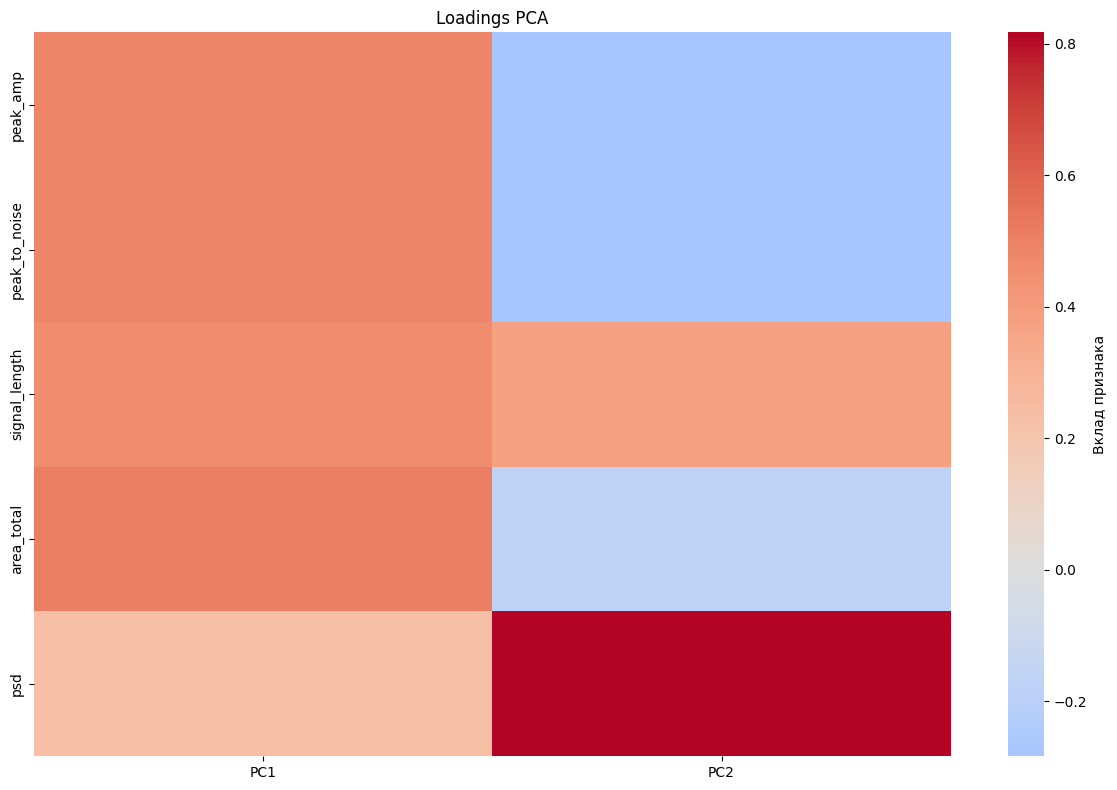


PC1:
  area_total: 0.506 (знак +1)
  peak_amp: 0.490 (знак +1)
  peak_to_noise: 0.490 (знак +1)
  signal_length: 0.457 (знак +1)
  psd: 0.236 (знак +1)

PC2:
  psd: 0.817 (знак +1)
  signal_length: 0.376 (знак +1)
  peak_amp: 0.283 (знак -1)
  peak_to_noise: 0.283 (знак -1)
  area_total: 0.174 (знак -1)


In [ ]:
# визуализация компонент
loadings = pca095.components_.T
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca095.n_components_)],
    index=FEATURE_COLS
)

# Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(loadings_df, cmap='coolwarm', center=0, annot=False,
            cbar_kws={'label': 'Вклад признака'})
plt.title('Loadings PCA')
plt.tight_layout()
plt.show()

# Топ-5 признаков для каждой компоненты
for i in range(pca095.n_components_):
    pc_name = f'PC{i+1}'
    top = loadings_df[pc_name].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc_name}:")
    for feat, val in top.items():
        sign = loadings_df.loc[feat, pc_name] / val
        print(f"  {feat}: {val:.3f} (знак {np.sign(sign):+.0f})")

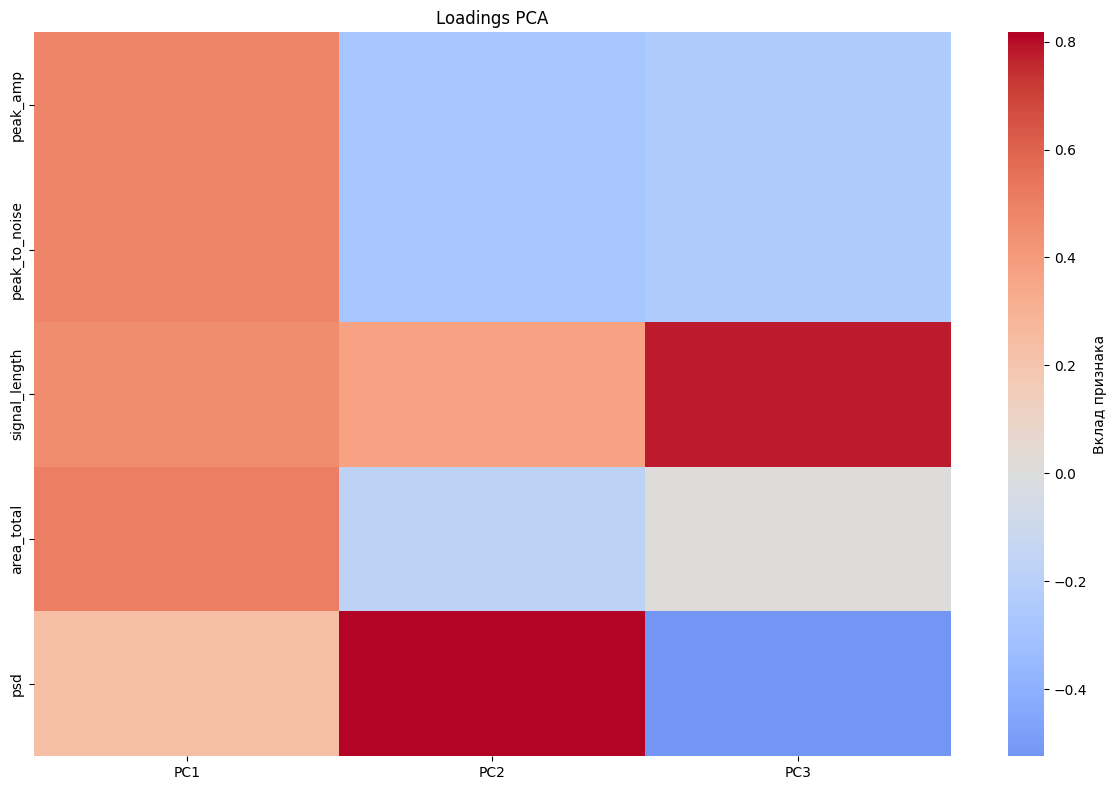


PC1:
  area_total: 0.506 (знак +1)
  peak_amp: 0.490 (знак +1)
  peak_to_noise: 0.490 (знак +1)
  signal_length: 0.457 (знак +1)
  psd: 0.236 (знак +1)

PC2:
  psd: 0.817 (знак +1)
  signal_length: 0.376 (знак +1)
  peak_amp: 0.283 (знак -1)
  peak_to_noise: 0.283 (знак -1)
  area_total: 0.174 (знак -1)

PC3:
  signal_length: 0.778 (знак +1)
  psd: 0.524 (знак -1)
  peak_amp: 0.245 (знак -1)
  peak_to_noise: 0.243 (знак -1)
  area_total: 0.014 (знак +1)


In [ ]:
# визуализация компонент
loadings = pca099.components_.T
loadings_df = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(pca099.n_components_)],
    index=FEATURE_COLS
)

# Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(loadings_df, cmap='coolwarm', center=0, annot=False,
            cbar_kws={'label': 'Вклад признака'})
plt.title('Loadings PCA')
plt.tight_layout()
plt.show()

# Топ-5 признаков для каждой компоненты
for i in range(pca099.n_components_):
    pc_name = f'PC{i+1}'
    top = loadings_df[pc_name].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc_name}:")
    for feat, val in top.items():
        sign = loadings_df.loc[feat, pc_name] / val
        print(f"  {feat}: {val:.3f} (знак {np.sign(sign):+.0f})")

Проведены тесты с несколькими наборами признаков, лучше всего себя показали: "peak_amp", "peak_to_noise", "signal_length", "area_total", "psd".

К данным применен StandardScaler.
Сохранено две выборки с 2 и 3 итоговыми компонетами, которые объясняют 0.98 и 0.99 дисперсии.

## Подбор гиперпараметров

In [ ]:
def evaluate_clustering(X, labels, noise_label=None):
    labels = np.asarray(labels)

    if noise_label is None:
        mask = np.ones(len(labels), dtype=bool)
    else:
        mask = labels != noise_label

    X_eff = X[mask]
    labels_eff = labels[mask]
    unique_labels = np.unique(labels_eff)

    out = {
        "n_points": len(labels),
        "n_used": int(mask.sum()),
        "noise_frac": float(1 - mask.mean()) if noise_label is not None else 0.0,
        "n_clusters": int(len(unique_labels)),
    }

    if len(unique_labels) < 2 or len(labels_eff) < 3:
        out.update({
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "min_cluster_size": np.nan,
        })
        return out

    sizes = pd.Series(labels_eff).value_counts()
    out.update({
        "silhouette": silhouette_score(X_eff, labels_eff),
        "davies_bouldin": davies_bouldin_score(X_eff, labels_eff),
        "calinski_harabasz": calinski_harabasz_score(X_eff, labels_eff),
        "min_cluster_size": int(sizes.min()),
    })
    return out

GMM


In [ ]:
def search_gmm(data_dict, covariance_types=("full", "diag", "tied")):
    grid = [(name, X, cov) for name, X in data_dict.items() for cov in covariance_types]
    rows = []

    for name, X, cov in tqdm(grid, total=len(grid), desc="GMM search"):
        model = GaussianMixture(
            n_components=3,
            covariance_type=cov,
            random_state=RANDOM_STATE,
            n_init=20,
        )
        labels = model.fit_predict(X)
        metrics = evaluate_clustering(X, labels)
        rows.append({
            "model": "GaussianMixture",
            "X": name,
            "covariance_type": cov,
            "bic": model.bic(X),
            "aic": model.aic(X),
            **metrics,
        })

    return pd.DataFrame(rows)

gmm_res = search_gmm(
    data_dict,
    covariance_types=("full", "diag", "tied")
)

print(gmm_res.sort_values(["silhouette", "davies_bouldin", "bic"], ascending=[False, True, True]).head(15))

GMM search:   0%|          | 0/6 [00:00<?, ?it/s]

             model              X covariance_type            bic  \
1  GaussianMixture  X_reduced_095            diag  130729.877182   
2  GaussianMixture  X_reduced_095            tied  143335.289536   
5  GaussianMixture  X_reduced_099            tied  142185.401965   
4  GaussianMixture  X_reduced_099            diag  111165.080312   
3  GaussianMixture  X_reduced_099            full   79207.627918   
0  GaussianMixture  X_reduced_095            full  121198.438971   

             aic  n_points  n_used  noise_frac  n_clusters  silhouette  \
1  130616.983119     23479   23479         0.0           3    0.468540   
2  143246.587058     23479   23479         0.0           3    0.468446   
5  142048.316317     23479   23479         0.0           3    0.453683   
4  111003.803078     23479   23479         0.0           3    0.417682   
3   78973.775929     23479   23479         0.0           3    0.402044   
0  121061.353323     23479   23479         0.0           3    0.374427   

   d

DBSCAN

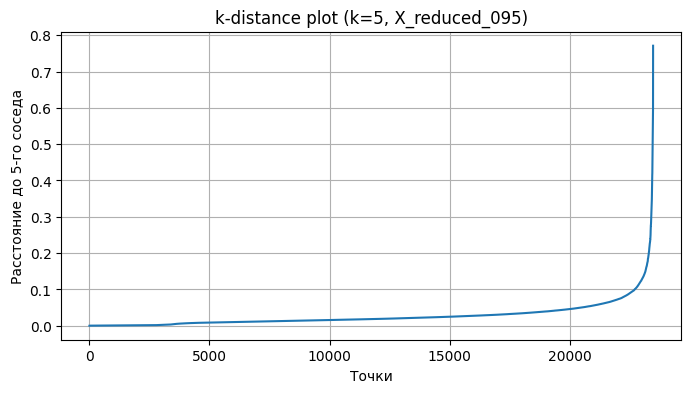

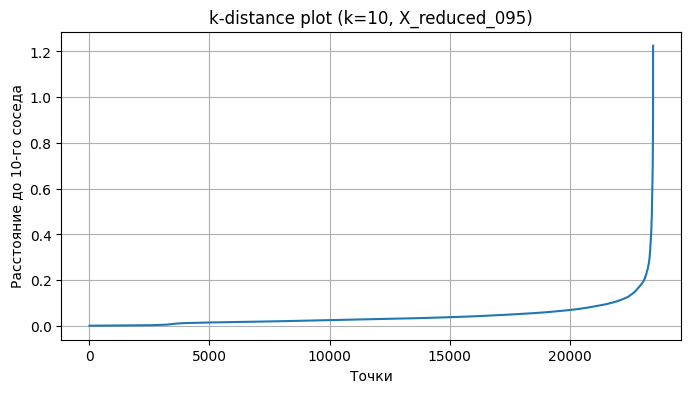

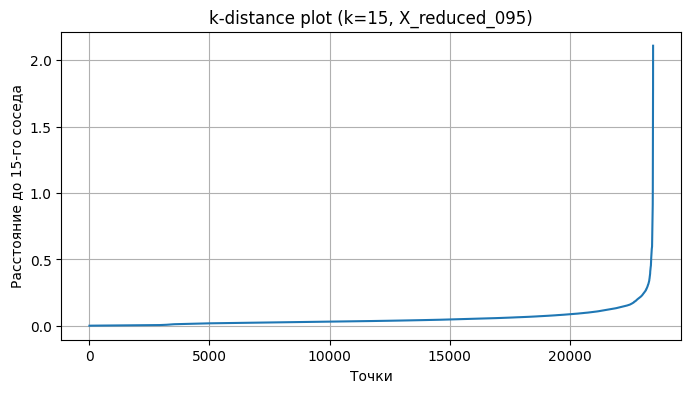

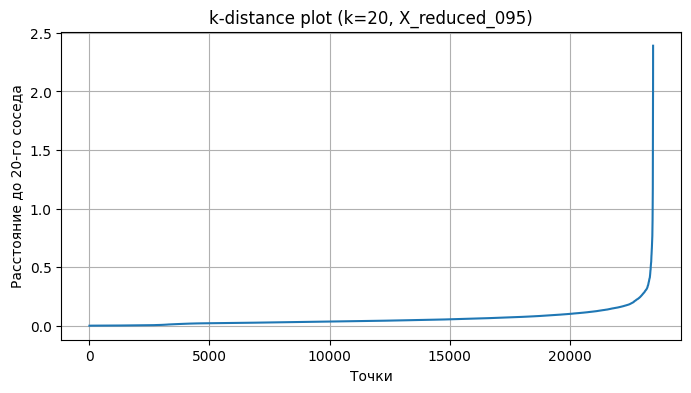

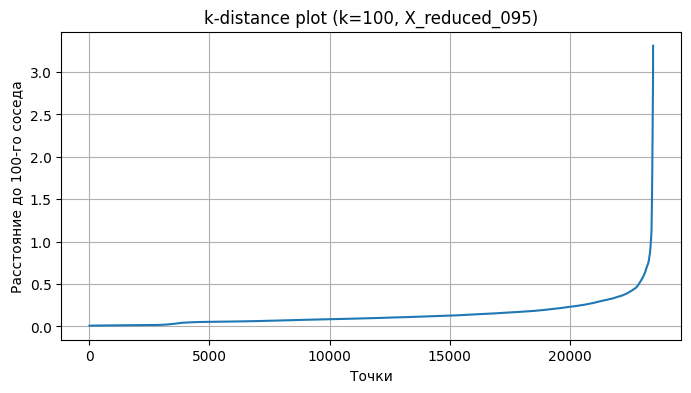

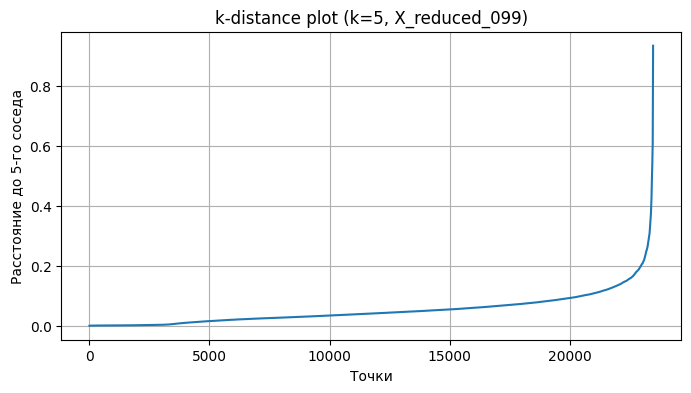

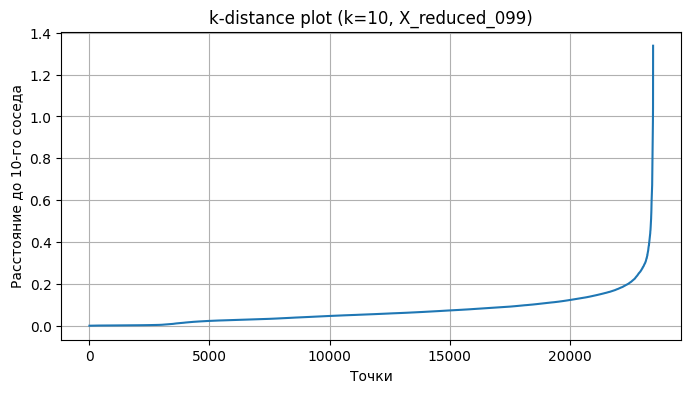

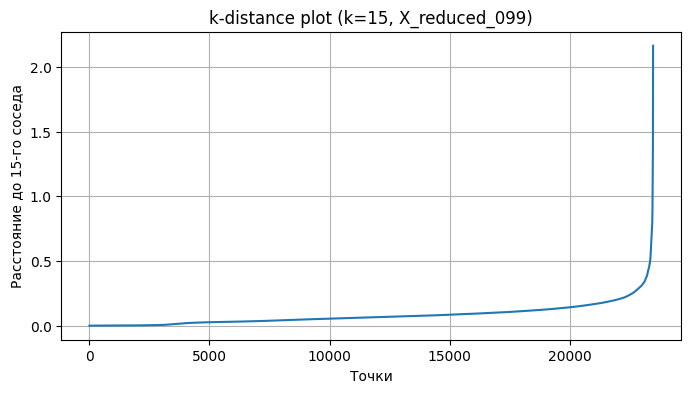

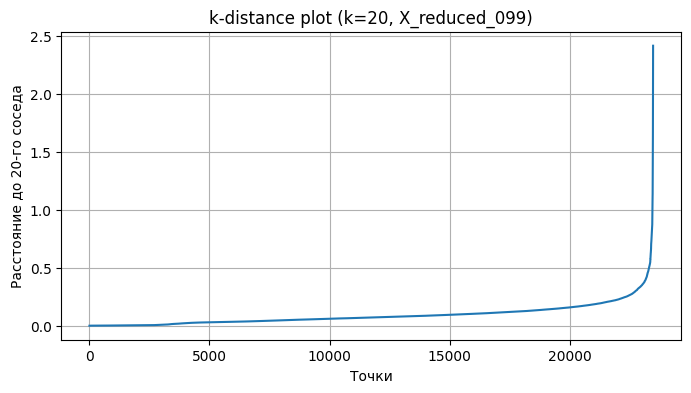

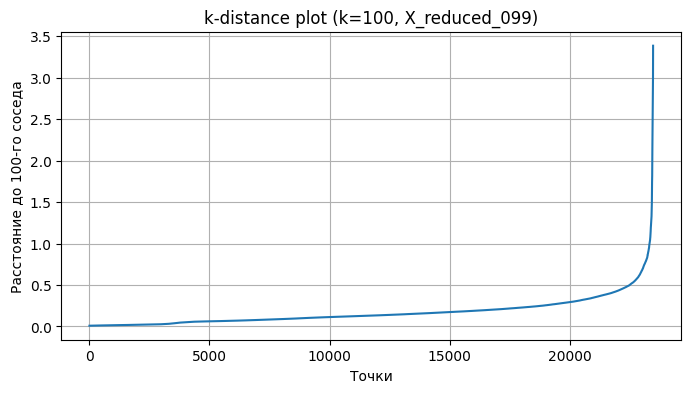

In [ ]:
k_vars = [5, 10, 15, 20, 100]
for name, X in data_dict.items():
    for k in k_vars:
        nbrs = NearestNeighbors(n_neighbors=k)
        nbrs.fit(X)

        distances, _ = nbrs.kneighbors(X)
        kdist = np.sort(distances[:, -1])

        plt.figure(figsize=(8, 4))
        plt.plot(kdist)
        plt.title(f"k-distance plot (k={k}, {name})")
        plt.xlabel("Точки")
        plt.ylabel(f"Расстояние до {k}-го соседа")
        plt.grid(True)
        plt.show()


In [ ]:
def search_dbscan(dataset_name, X, eps_grid, min_samples_grid):
    rows = []

    for eps in tqdm(eps_grid, desc=f"DBSCAN {dataset_name} - eps", leave=False):
        for ms in min_samples_grid:
            db = DBSCAN(eps=float(eps), min_samples=int(ms))
            raw = db.fit_predict(X)

            uniq = np.unique(raw)
            if len(uniq) < 2:
                continue

            # Присваиваем шум ближайшему кластеру
            labels = raw.copy()
            cluster_ids = [u for u in np.unique(labels) if u != -1]
            if len(cluster_ids) == 0:
                continue

            # Вычисляем центроиды кластеров (игнорируя шум)
            centroids = {u: X[labels == u].mean(axis=0) for u in cluster_ids}
            noise_idx = np.where(labels == -1)[0]

            if len(noise_idx) > 0:
                C = np.vstack([centroids[u] for u in cluster_ids])
                for i in noise_idx:
                    dists = np.linalg.norm(C - X[i], axis=1)
                    labels[i] = cluster_ids[int(np.argmin(dists))]

            # Добавить проверку: минимум 2 кластера
            if len(np.unique(labels)) < 2:
                continue

            # Метрика
            score = silhouette_score(X, labels)

            rows.append({
                "dataset": dataset_name,
                "model": "DBSCAN",
                "eps": float(eps),
                "min_samples": int(ms),
                "n_clusters": len(np.unique(labels)),
                "silhouette": score,

            })
    return rows

param_grids = {
    "X_reduced_095": {
        "eps": [0.1, 0.18, 0.25, 0.25, 0.5],
        "min_samples": k_vars
    },
    "X_reduced_099": {
        "eps": [0.2, 0.28, 0.4, 0.4, 0.5],
        "min_samples": k_vars
    }
}

all_results = []

for name, X in data_dict.items():
    eps_grid = param_grids[name]["eps"]
    ms_grid = param_grids[name]["min_samples"]

    rows = search_dbscan(name, X, eps_grid, ms_grid)
    all_results.extend(rows)

dbscan_res = pd.DataFrame(all_results)


print(dbscan_res.sort_values("silhouette", ascending=False).head(15))

DBSCAN X_reduced_095 - eps:   0%|          | 0/5 [00:00<?, ?it/s]

DBSCAN X_reduced_099 - eps:   0%|          | 0/5 [00:00<?, ?it/s]

          dataset   model   eps  min_samples  n_clusters  silhouette
12  X_reduced_095  DBSCAN  0.50            5           2    0.714021
24  X_reduced_099  DBSCAN  0.50            5           2    0.691212
25  X_reduced_099  DBSCAN  0.50           10           2    0.681538
10  X_reduced_095  DBSCAN  0.25            5           2    0.662213
8   X_reduced_095  DBSCAN  0.25            5           2    0.662213
23  X_reduced_099  DBSCAN  0.40           10           2    0.658094
21  X_reduced_099  DBSCAN  0.40           10           2    0.658094
22  X_reduced_099  DBSCAN  0.40            5           3    0.644276
20  X_reduced_099  DBSCAN  0.40            5           3    0.644276
9   X_reduced_095  DBSCAN  0.25           20           2    0.611048
11  X_reduced_095  DBSCAN  0.25           20           2    0.611048
19  X_reduced_099  DBSCAN  0.28           15           2    0.599674
7   X_reduced_095  DBSCAN  0.18           15           2    0.592100
17  X_reduced_099  DBSCAN  0.20   

In [ ]:
def search_dbscan(dataset_name, X, param_list):
    """
    param_list: список кортежей (min_samples, eps_list)
    Например: [(5, [0.09,0.1,0.11]), (10, [0.16,0.18,0.20]), ...]
    """
    rows = []
    for ms, eps_list in param_list:
        for eps in eps_list:
            db = DBSCAN(eps=eps, min_samples=ms)
            raw = db.fit_predict(X)
            if len(np.unique(raw)) < 2:
                continue
            labels = raw.copy()
            cluster_ids = [u for u in np.unique(labels) if u != -1]
            if not cluster_ids:
                continue
            centroids = {u: X[labels == u].mean(axis=0) for u in cluster_ids}
            noise_idx = np.where(labels == -1)[0]
            if len(noise_idx) > 0:
                C = np.vstack([centroids[u] for u in cluster_ids])
                for i in noise_idx:
                    dists = np.linalg.norm(C - X[i], axis=1)
                    labels[i] = cluster_ids[np.argmin(dists)]
            if len(np.unique(labels)) < 2:
                continue
            score = silhouette_score(X, labels)
            rows.append({
                "dataset": dataset_name,
                "model": "DBSCAN",
                "eps": eps,
                "min_samples": ms,
                "n_clusters": len(np.unique(labels)),
                "silhouette": score
            })
    return rows

# Пример задания окрестностей для каждого k (после анализа графиков)
param_list_095 = [
    (5,  [0.09, 0.1, 0.11]),
    (10, [0.16, 0.18, 0.20]),
    (15, [0.23, 0.25, 0.27]),
    (20, [0.23, 0.25, 0.27]),
    (100,[0.45, 0.5, 0.55])
]

param_list_099 = [
    (5,  [0.18, 0.2, 0.22]),
    (10, [0.26, 0.28, 0.30]),
    (15, [0.38, 0.4, 0.42]),
    (20, [0.38, 0.4, 0.42]),
    (100,[0.45, 0.5, 0.55])
]

all_results = []
for name, X in data_dict.items():
    if name == "X_reduced_095":
        param_list = param_list_095
    else:
        param_list = param_list_099
    all_results.extend(search_dbscan(name, X, param_list))

dbscan_res = pd.DataFrame(all_results)
print(dbscan_res.sort_values("silhouette", ascending=False).head(15))

          dataset   model   eps  min_samples  n_clusters  silhouette
5   X_reduced_095  DBSCAN  0.20           10           2    0.619767
9   X_reduced_095  DBSCAN  0.27           20           2    0.618088
6   X_reduced_095  DBSCAN  0.23           15           2    0.615395
8   X_reduced_095  DBSCAN  0.25           20           2    0.611048
13  X_reduced_099  DBSCAN  0.26           10           2    0.606861
7   X_reduced_095  DBSCAN  0.23           20           2    0.602197
3   X_reduced_095  DBSCAN  0.16           10           8    0.427029
4   X_reduced_095  DBSCAN  0.18           10           4    0.389055
12  X_reduced_099  DBSCAN  0.22            5           6    0.282631
11  X_reduced_099  DBSCAN  0.20            5          11    0.216162
10  X_reduced_099  DBSCAN  0.18            5          16    0.190015
2   X_reduced_095  DBSCAN  0.11            5          18    0.077807
1   X_reduced_095  DBSCAN  0.10            5          23    0.043292
0   X_reduced_095  DBSCAN  0.09   

HDBSCAN

In [ ]:
def search_hdbscan(data_dict, mcs_grid, ms_grid, eps_grid):
    grid = [(name, X, mcs, ms, eps) for name, X in data_dict.items() for mcs in mcs_grid for ms in ms_grid for eps in eps_grid]
    rows = []

    for name, X, mcs, ms, eps in tqdm(grid, total=len(grid), desc="HDBSCAN search"):
        hb = hdbscan.HDBSCAN(
            min_cluster_size=int(mcs),
            min_samples=None if ms is None else int(ms),
            cluster_selection_method="eom",
            cluster_selection_epsilon=eps
        )
        raw = hb.fit_predict(X)

        uniq = np.unique(raw)
        if len(uniq) < 2:
            continue

        labels = raw.copy()
        cluster_ids = [u for u in np.unique(labels) if u != -1]

        if len(cluster_ids) == 0:
            continue

        centroids = {u: X[labels == u].mean(axis=0) for u in cluster_ids}
        noise_idx = np.where(labels == -1)[0]

        if len(noise_idx) > 0:
            C = np.vstack([centroids[u] for u in cluster_ids])
            for i in noise_idx:
                dists = np.linalg.norm(C - X[i], axis=1)
                labels[i] = cluster_ids[int(np.argmin(dists))]

        # if len(np.unique(labels)) != 3:
        #     continue

        score = silhouette_score(X, labels)

        rows.append({
            "model": "HDBSCAN",
            "X": name,
            "min_cluster_size": mcs,
            "min_samples": ms,
            "eps": eps,
            "n_clusters": len(np.unique(labels)),
            "score": score
        })

    return pd.DataFrame(rows)

hdbscan_results = []

mcs_grid = [40, 50, 80, 120]
ms_grid = [None, 10, 20, 50, 100]
eps_grid = [0.01, 0.03, 0.05, 0.08, 0.1]

hdbscan_res = search_hdbscan(data_dict, mcs_grid, ms_grid, eps_grid)
print(hdbscan_res.sort_values("score", ascending=False).head(15))

HDBSCAN search:   0%|          | 0/200 [00:00<?, ?it/s]

       model              X  min_cluster_size  min_samples   eps  n_clusters  \
64   HDBSCAN  X_reduced_095                80         20.0  0.10           2   
63   HDBSCAN  X_reduced_095                80         20.0  0.08           2   
59   HDBSCAN  X_reduced_095                80         10.0  0.10           2   
58   HDBSCAN  X_reduced_095                80         10.0  0.08           2   
83   HDBSCAN  X_reduced_095               120         10.0  0.08           2   
84   HDBSCAN  X_reduced_095               120         10.0  0.10           2   
88   HDBSCAN  X_reduced_095               120         20.0  0.08           2   
89   HDBSCAN  X_reduced_095               120         20.0  0.10           2   
34   HDBSCAN  X_reduced_095                50         10.0  0.10           3   
33   HDBSCAN  X_reduced_095                50         10.0  0.08           3   
159  HDBSCAN  X_reduced_099                80         10.0  0.10           2   
158  HDBSCAN  X_reduced_099             

Поиск гиперпараметров осуществлен для GMM, DBSCAN и HDBSCAN и для двух видов выборки - с компонентами, объясняющими 95% и 99% дисперсии. Сравнение идет по silhouette, для GMM также учитываются bic, noise_fraq. Отбираются модели, дающие 3 кластера, как сказано в условии.

# Обучение лучших моделей

In [ ]:
best_models = {
    "GMM_095_diag": {
        "X": X_reduced_095,
        "model": GaussianMixture(
            n_components=3,
            covariance_type="diag",
            random_state=RANDOM_STATE,
            n_init=20,
        ),
    },
    "DBSCAN_099_eps040_ms5": {
        "X": X_reduced_099,
        "model": DBSCAN(
            eps=0.40,
            min_samples=5,
        ),
    },
    "HDBSCAN_095_mcs50_ms10_eps010": {
        "X": X_reduced_095,
        "model": hdbscan.HDBSCAN(
            min_cluster_size=50,
            min_samples=10,
            cluster_selection_method="eom",
            cluster_selection_epsilon=0.10,
        ),
    },
}

In [ ]:
# Вспомогательные функции

def remap_first_appearance(labels):
    """Перенумерация меток по порядку первого появления."""
    mapping = {}
    next_label = 0
    out = []
    for v in labels:
        v = int(v)
        if v not in mapping:
            mapping[v] = next_label
            next_label += 1
        out.append(mapping[v])
    return np.asarray(out, dtype=int), mapping


def assign_noise_to_nearest(X, labels):
    """
    Для DBSCAN/HDBSCAN:
    - шум (-1) присваиваем ближайшему кластеру по евклидовой дистанции.
    """
    labels = np.asarray(labels, dtype=int).copy()
    uniq = [u for u in np.unique(labels) if u != -1]
    if len(uniq) == 0:
        return None

    centroids = {u: X[labels == u].mean(axis=0) for u in uniq}
    noise_idx = np.where(labels == -1)[0]

    if len(noise_idx) > 0:
        C = np.vstack([centroids[u] for u in uniq])
        for i in noise_idx:
            dists = np.linalg.norm(C - X[i], axis=1)
            labels[i] = uniq[int(np.argmin(dists))]

    return labels


def make_submission(labels, name):

    submission = pd.DataFrame({
      "index": np.arange(len(labels)),
      "cluster": labels.astype(int)
    })

    submission.to_csv(f"{name}.csv", index=False)

    files.download(f"{name}.csv")

In [ ]:
# GMM
chosen = best_models["GMM_095_diag"]
model, X = chosen["model"], chosen["X"]

raw_labels = model.fit_predict(X)
labels, mapping = remap_first_appearance(raw_labels)

make_submission(labels, "GMM_095_diag")



mapping: {2: 0, 1: 1, 0: 2}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

mapping: {0: 0, 1: 1, 2: 2}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

mapping: {2: 0, 0: 1, 1: 2}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

# DBSCAN
chosen = best_models["DBSCAN_099_eps040_ms5"]
model, X = chosen["model"], chosen["X"]

raw_labels = model.fit_predict(X)
labels = assign_noise_to_nearest(X, raw_labels)
labels, mapping = remap_first_appearance(labels)

make_submission(labels, "DBSCAN_099_eps040_ms5")



In [ ]:

# HDBSCAN
chosen = best_models["HDBSCAN_095_mcs50_ms10_eps010"]
model, X = chosen["model"], chosen["X"]

raw_labels = model.fit_predict(X)
labels = assign_noise_to_nearest(X, raw_labels)
labels, mapping = remap_first_appearance(labels)

make_submission(labels, "HDBSCAN_095_mcs50_ms10_eps010")

Из проверенных моделей лучший результат получился у GMM_095_diag

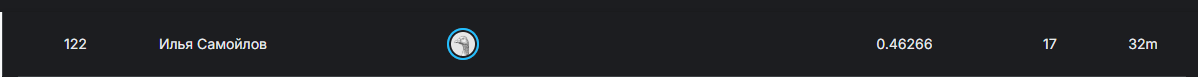